In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load your CSV file
df = pd.read_csv("C:\\Users\\amish\\Downloads\\traffic_accidents.csv")
# Cleaning columns 
df.columns = [col.strip().lower().replace(' ', '_') for col in df.columns]
print("Rows & Columns:", df.shape)
print("Column Names:\n", df.columns.tolist())
df.head()

Rows & Columns: (209306, 24)
Column Names:
 ['crash_date', 'traffic_control_device', 'weather_condition', 'lighting_condition', 'first_crash_type', 'trafficway_type', 'alignment', 'roadway_surface_cond', 'road_defect', 'crash_type', 'intersection_related_i', 'damage', 'prim_contributory_cause', 'num_units', 'most_severe_injury', 'injuries_total', 'injuries_fatal', 'injuries_incapacitating', 'injuries_non_incapacitating', 'injuries_reported_not_evident', 'injuries_no_indication', 'crash_hour', 'crash_day_of_week', 'crash_month']


,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
0,07/29/2023 01:00:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,13,7,7
1,08/13/2023 12:11:00 AM,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0,1,8
2,12/09/2021 10:30:00 AM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,10,5,12
3,08/09/2023 07:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,NONINCAPACITATING INJURY,5.0,0.0,0.0,5.0,0.0,0.0,19,4,8
4,08/19/2023 02:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,14,7,8


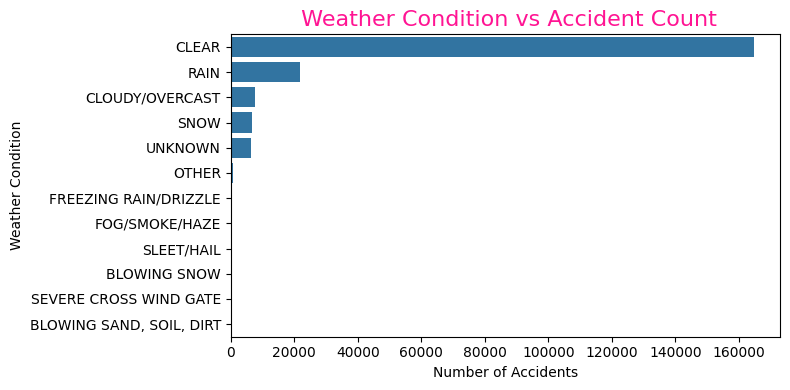

In [2]:
#Weather Condition vs Number of Accidents
plt.figure(figsize=(8,4))
sns.countplot(y='weather_condition', data=df, order=df['weather_condition'].value_counts().index)
plt.title(" Weather Condition vs Accident Count", fontsize=16, color='deeppink')
plt.xlabel("Number of Accidents")
plt.ylabel("Weather Condition")
plt.tight_layout()
plt.show()

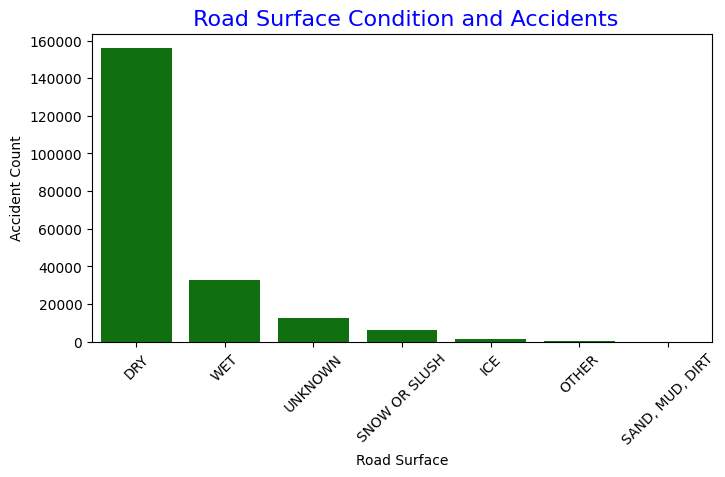

In [30]:
#Road Surface Condition vs Accidents
plt.figure(figsize=(8, 4))
sns.countplot(x='roadway_surface_cond',color="green", data=df, order=df['roadway_surface_cond'].value_counts().index)
plt.title(" Road Surface Condition and Accidents", fontsize=16, color='blue')
plt.xticks(rotation=45)
plt.xlabel("Road Surface")
plt.ylabel("Accident Count")
plt.show()

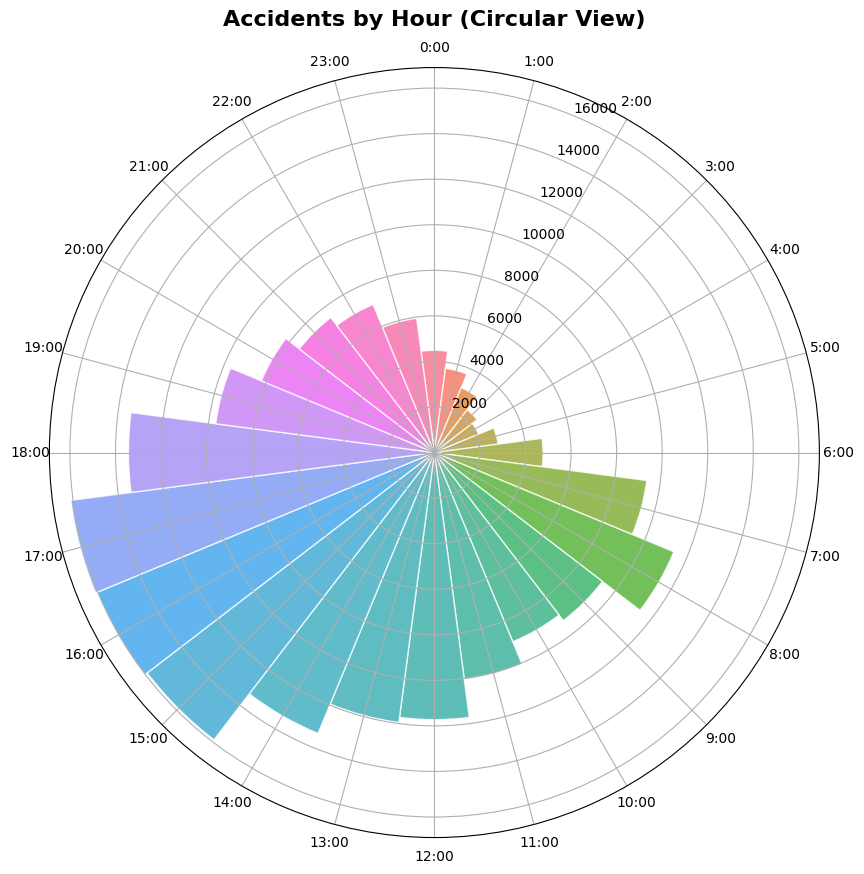

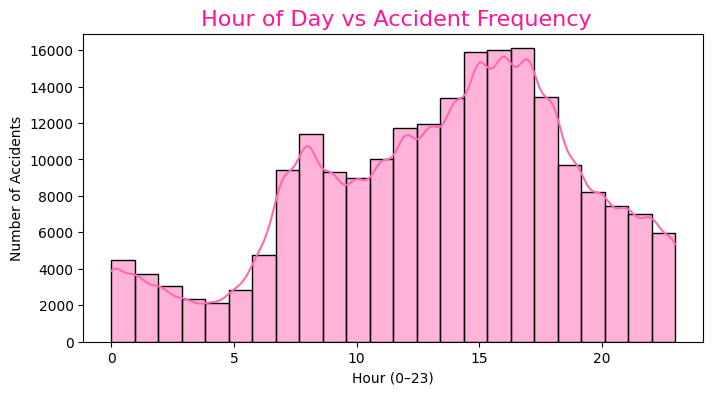

In [22]:
#Hour of the Day vs Accident Frequency

plt.figure(figsize=(10, 10))
ax = plt.subplot(projection='polar')

hours = np.arange(0, 24)
values = df['crash_hour'].value_counts().sort_index().reindex(hours, fill_value=0)
theta = np.linspace(0, 2*np.pi, 24, endpoint=False)

bars = ax.bar(theta, values, width=2*np.pi/24, 
              color=sns.color_palette('husl', 24),
              alpha=0.8, edgecolor='white')

ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_xticks(theta)
ax.set_xticklabels([f'{h}:00' for h in range(24)])
plt.title('Accidents by Hour (Circular View)', 
          pad=30, fontsize=16, fontweight='bold')
plt.show()


plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='crash_hour', bins=24, kde=True, color='hotpink')
plt.title(" Hour of Day vs Accident Frequency", fontsize=16, color='deeppink')
plt.xlabel("Hour (0–23)")
plt.ylabel("Number of Accidents")
plt.show()

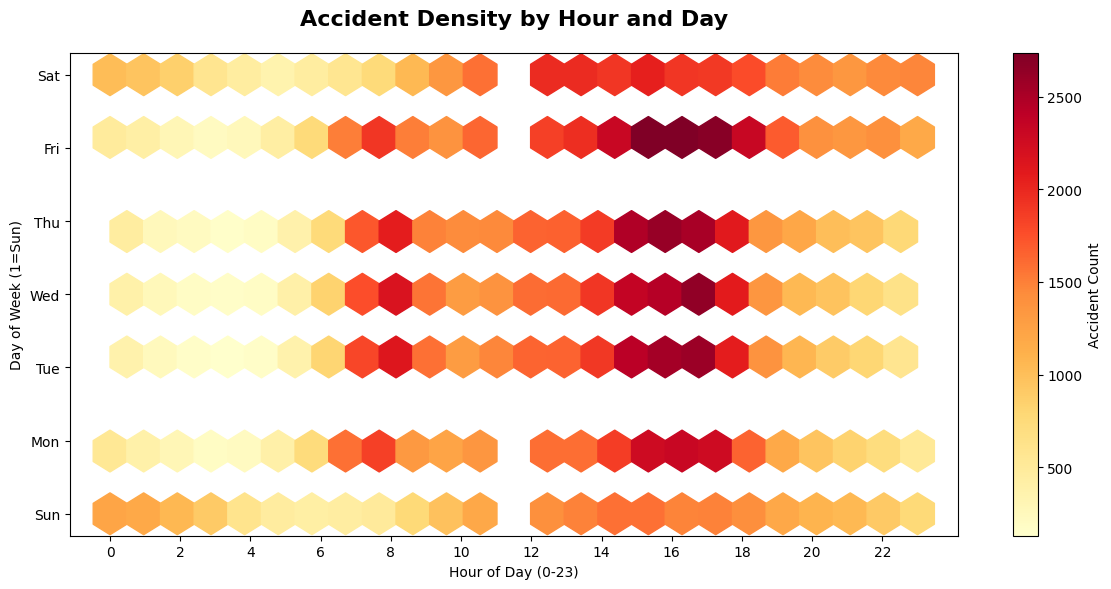

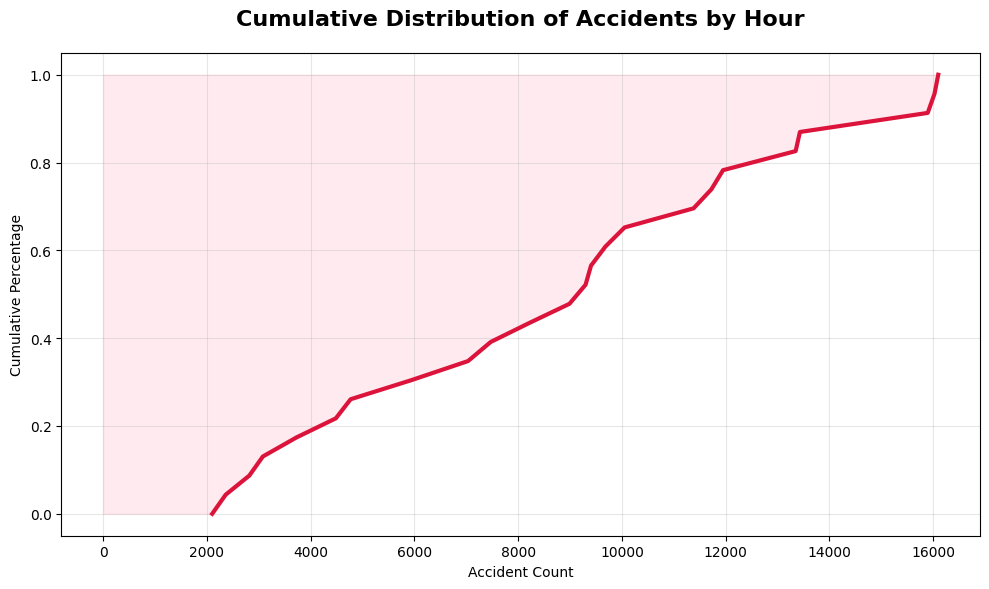

<Figure size 1400x800 with 0 Axes>

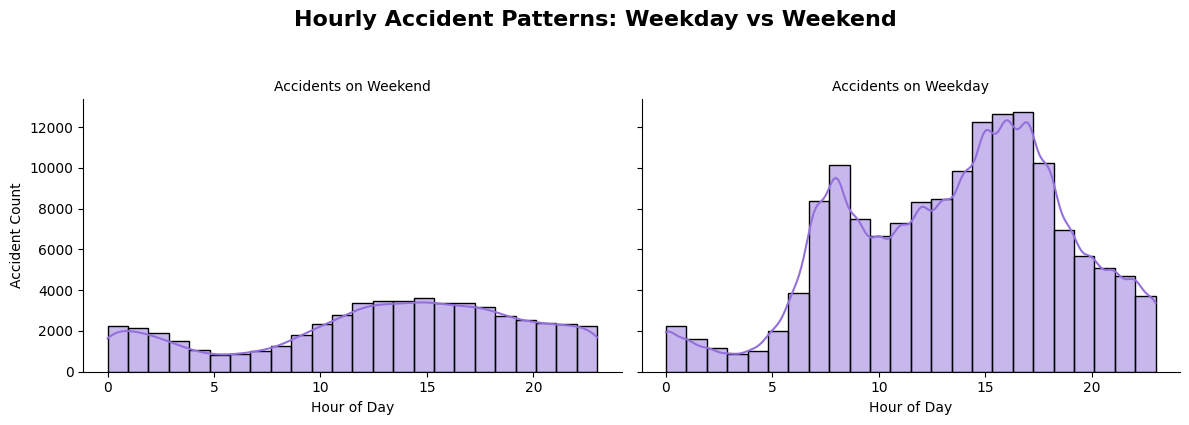

In [25]:
plt.figure(figsize=(12, 6))
plt.hexbin(x=df['crash_hour'], 
           y=df.get('crash_day_of_week', 0),  # Use if day data exists
           gridsize=(24, 7), 
           cmap='YlOrRd',
           mincnt=1)

plt.colorbar(label='Accident Count')
plt.title('Accident Density by Hour and Day', 
          pad=20, fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Day of Week (1=Sun)')
plt.xticks(np.arange(0, 24, 2))
plt.yticks(range(1,8), ['Sun','Mon','Tue','Wed','Thu','Fri','Sat'])
plt.tight_layout()
plt.show()



plt.figure(figsize=(10, 6))
sorted_vals = np.sort(df['crash_hour'].value_counts().values)
plt.plot(sorted_vals, np.linspace(0, 1, len(sorted_vals)), 
         color='crimson', lw=3)

plt.fill_betweenx(np.linspace(0, 1, len(sorted_vals)), 
                  sorted_vals, 
                  color='pink', alpha=0.3)

plt.title('Cumulative Distribution of Accidents by Hour', 
          pad=20, fontsize=16, fontweight='bold')
plt.xlabel('Accident Count')
plt.ylabel('Cumulative Percentage')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



plt.figure(figsize=(14, 8))

# Create weekend/weekday flag if not present
if 'crash_day_of_week' in df.columns:
    df['day_type'] = df['crash_day_of_week'].apply(
        lambda x: 'Weekend' if x in [1, 7] else 'Weekday')
    
    g = sns.FacetGrid(df, col='day_type', height=4, aspect=1.5)
    g.map(sns.histplot, 'crash_hour', bins=24, 
          kde=True, color='mediumpurple')
    
    g.set_axis_labels("Hour of Day", "Accident Count")
    g.set_titles("Accidents on {col_name}")
    plt.suptitle('Hourly Accident Patterns: Weekday vs Weekend', 
                 y=1.05, fontsize=16, fontweight='bold')
    plt.tight_layout()
else:
    print("Day of week data not available for this visualization")


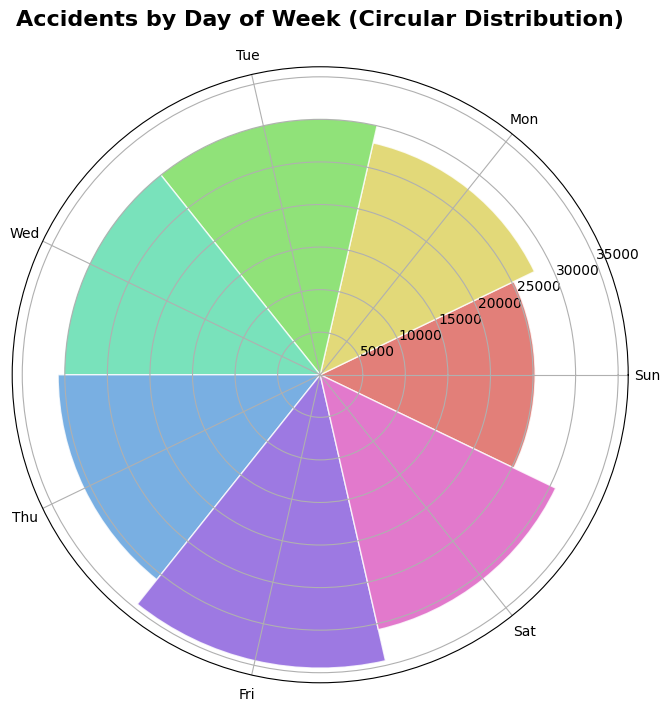

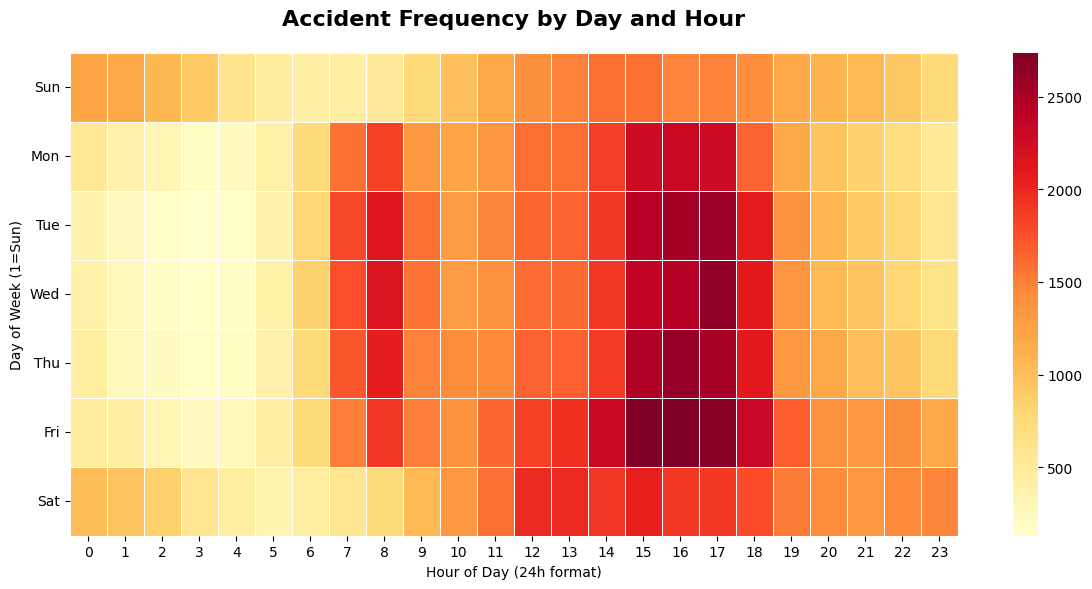

In [20]:
import numpy as np 
plt.figure(figsize=(10, 8))
ax = plt.subplot(polar=True)

day_counts = df['crash_day_of_week'].value_counts().sort_index()
days = ['Sun','Mon','Tue','Wed','Thu','Fri','Sat']
theta = np.linspace(0, 2*np.pi, len(days), endpoint=False)
width = 2*np.pi/len(days)

bars = ax.bar(theta, day_counts, width=width, color=sns.color_palette('hls', len(days)),
              alpha=0.8, edgecolor='white')

ax.set_xticks(theta)
ax.set_xticklabels(days)
ax.set_title('Accidents by Day of Week (Circular Distribution)', 
             pad=30, fontsize=16, fontweight='bold')

plt.show()






plt.figure(figsize=(12, 6))
hour_day = df.groupby(['crash_day_of_week', 'crash_hour']).size().unstack()
sns.heatmap(hour_day, cmap='YlOrRd', linewidths=0.5)
plt.title('Accident Frequency by Day and Hour', 
          pad=20, fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day (24h format)')
plt.ylabel('Day of Week (1=Sun)')
plt.yticks(np.arange(7)+0.5, days, rotation=0)
plt.tight_layout()
plt.show()


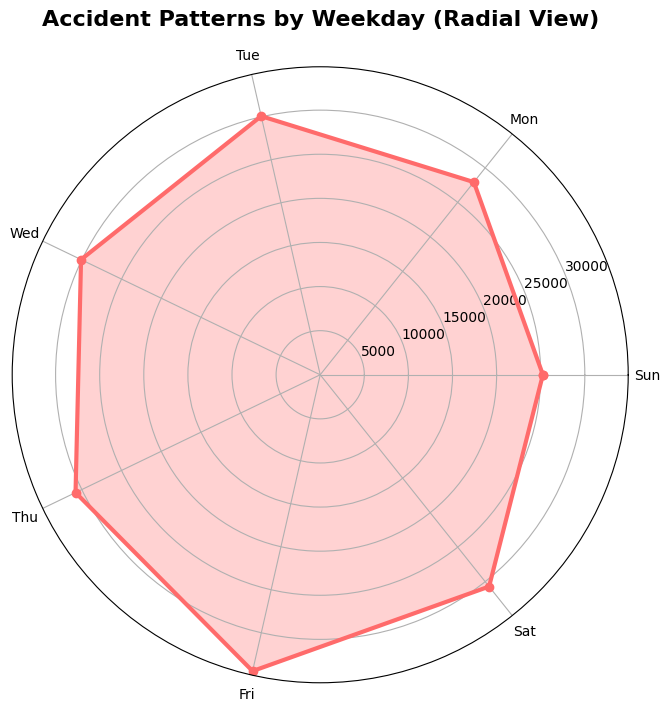

In [21]:
plt.figure(figsize=(10, 8))
ax = plt.subplot(polar=True)

day_counts = df['crash_day_of_week'].value_counts().sort_index()
theta = np.linspace(0, 2*np.pi, len(days), endpoint=False)

theta = np.concatenate((theta, [theta[0]]))
values = np.concatenate((day_counts, [day_counts.iloc[0]]))

ax.plot(theta, values, color='#FF6B6B', marker='o', linewidth=3)
ax.fill(theta, values, color='#FF6B6B', alpha=0.3)

ax.set_xticks(theta[:-1])
ax.set_xticklabels(days)
ax.set_title('Accident Patterns by Weekday (Radial View)',
             pad=30, fontsize=16, fontweight='bold')
plt.show()



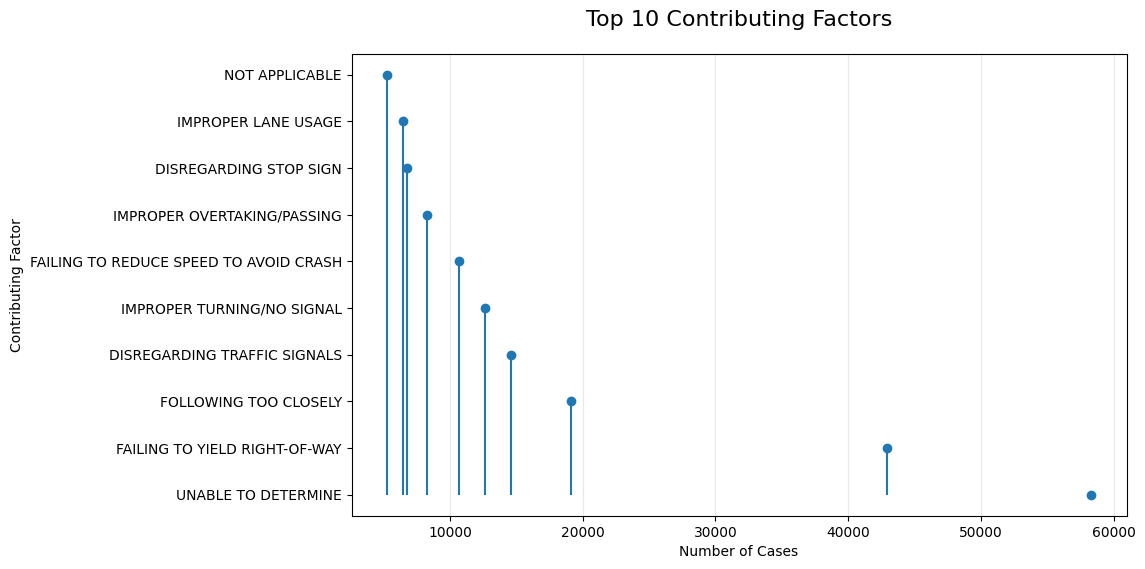

In [7]:
plt.figure(figsize=(10,6))
top_factors = df['prim_contributory_cause'].value_counts().head(10)
plt.stem(top_factors.values, top_factors.index, linefmt='C0-', markerfmt='C0o', basefmt=' ')
plt.title("Top 10 Contributing Factors", fontsize=16, pad=20)
plt.xlabel("Number of Cases")
plt.ylabel("Contributing Factor")
plt.grid(axis='x', alpha=0.3)
plt.show()


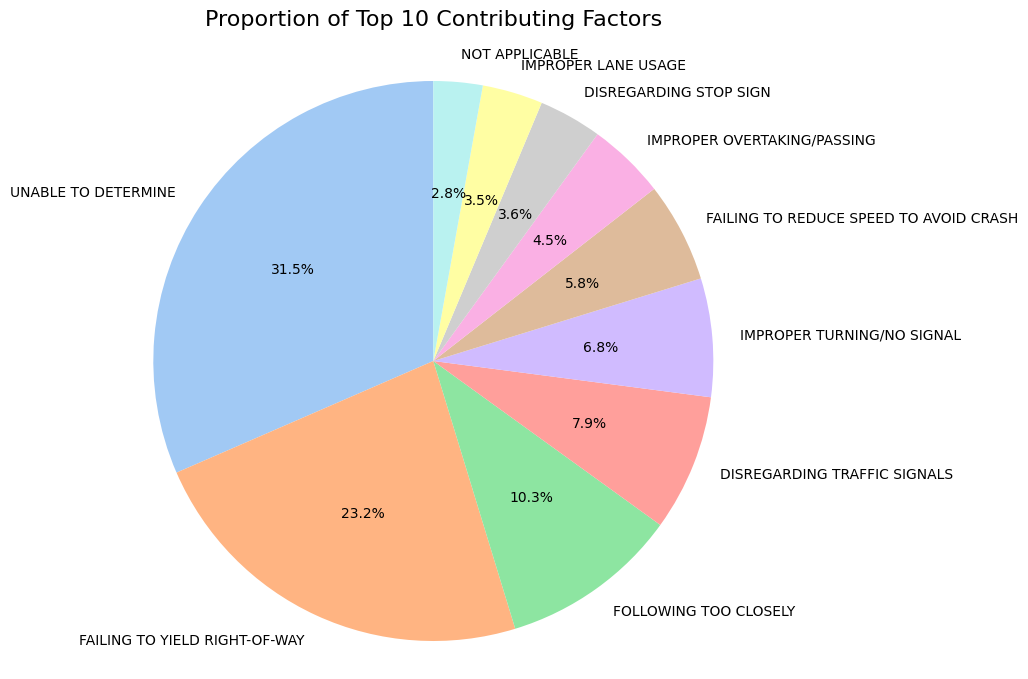

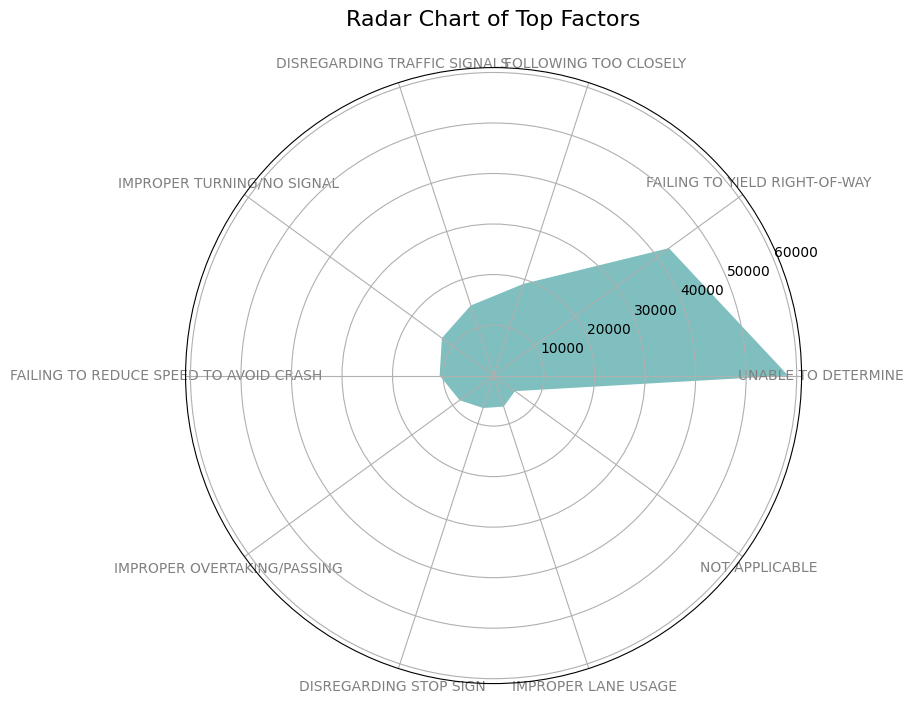

In [11]:
plt.figure(figsize=(10,8))
top_factors = df['prim_contributory_cause'].value_counts().head(10)
plt.pie(top_factors, labels=top_factors.index, autopct='%1.1f%%',
        startangle=90, colors=sns.color_palette('pastel'))
plt.title("Proportion of Top 10 Contributing Factors", fontsize=16, pad=20)
plt.axis('equal')
plt.show()


from math import pi
plt.figure(figsize=(10,8))
top_factors = df['prim_contributory_cause'].value_counts().head(10)
categories = top_factors.index
values = top_factors.values
N = len(categories)

angles = [n/float(N)*2*pi for n in range(N)]
values = list(values)
values += values[:1]
angles += angles[:1]

ax = plt.subplot(111, polar=True)
plt.xticks(angles[:-1], categories, color='grey', size=10)
plt.fill(angles, values, 'teal', alpha=0.5)
plt.title("Radar Chart of Top Factors", fontsize=16, pad=30)
plt.show()


